In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import os
from pathlib import Path
import histlite as hl
import json
import sys
sys.path.append(os.path.abspath("../../../"))
from kingmaker_fork.likelihood_analysis.analysis_helpers.plot_bias import plot_bias

In [2]:
run_folder = Path('/data/user/fkrafft/king_llh_binning_run')
new_bin_folder = Path('/data/user/fkrafft/csky_king_tests')
fitting_candidate = 'E5_a36baa_D9_83b58e_S12_MC300'
sin_decs = [-0.5, -0.1, 0.4]

new_binning_id = 'E5_a36baa_D9_83b58e_S12_MC300_PST_energy_bins_ext_gamma_range'


In [3]:
old_binning_dict = {}
ps_energy_bin_dict = {}
for s in sin_decs:
    candidate_id = f"SINDEC_{s}_NTRIALS_{1000}_{fitting_candidate}"
    old_path = os.path.join(run_folder, fitting_candidate, f"king_bias_{s}_{candidate_id}.pkl")
    new_path = os.path.join(new_bin_folder, new_binning_id, f'king_bias_{s}_N_1000_{new_binning_id}.json' )
    
    with open(old_path, "rb") as f:
        allt_old= pickle.load(f)
        old_binning_dict[s] = allt_old
    with open(new_path, "rb") as f:
        allt_ps = pickle.load(f)
        ps_energy_bin_dict[s] = allt_ps

In [4]:
n_sigs = np.r_[:101:10]
dns = np.mean(np.diff(n_sigs))
ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
expect_gamma = 2.5

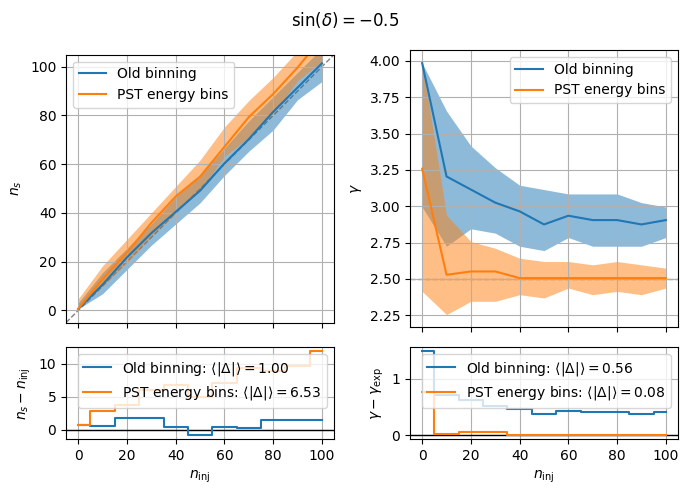

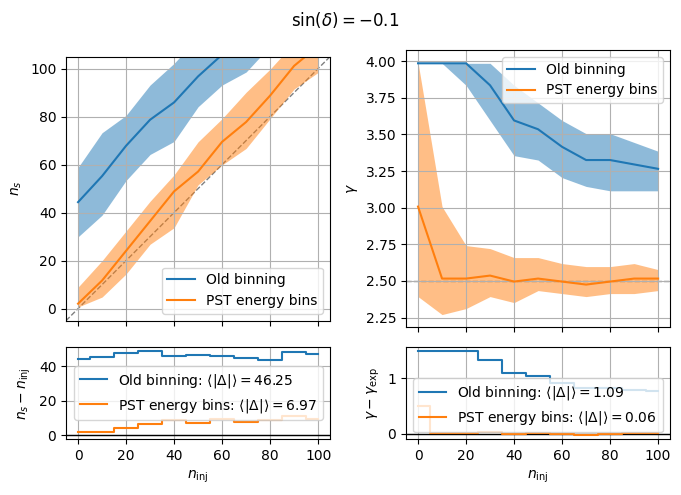

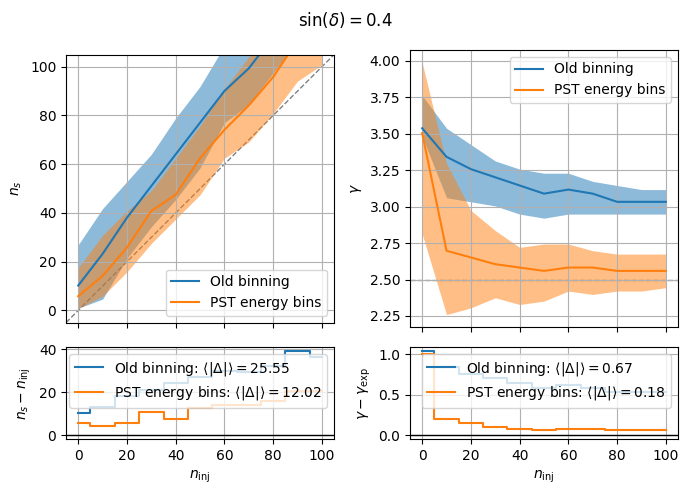

In [5]:
for s in sin_decs:
    data_old = old_binning_dict[s]
    data_new = ps_energy_bin_dict[s]
    plot_bias(data_1= data_old,
              data_2 = data_new,
              sindec= s,
              label_1= 'Old binning',
              label_2= 'PST energy bins',
              ns_bins = ns_bins,
              expect_gamma= expect_gamma)

### Plot PST bins vs. Rayleigh

In [6]:
rayleigh_benchmark_path = Path('/data/user/fkrafft/csky_gfu_tests/2023_sig_gamma_2.5_PS_energy_bins')
rayleigh_data = {}
for s in sin_decs:
    rayleigh_bias_path = os.path.join(rayleigh_benchmark_path, f'rayleigh_bias_{s}_N_100000_2023_sig_gamma_2.5_PS_energy_bins.json' )
    with open(rayleigh_bias_path, "rb") as f:
        ray_allt = pickle.load(f)
        rayleigh_data[s] = ray_allt

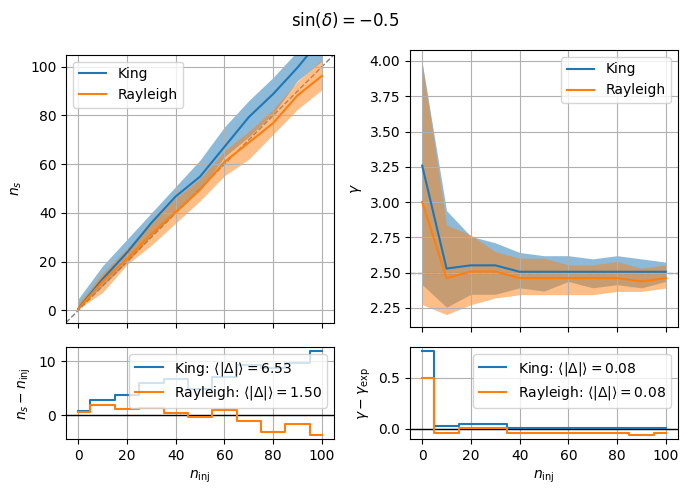

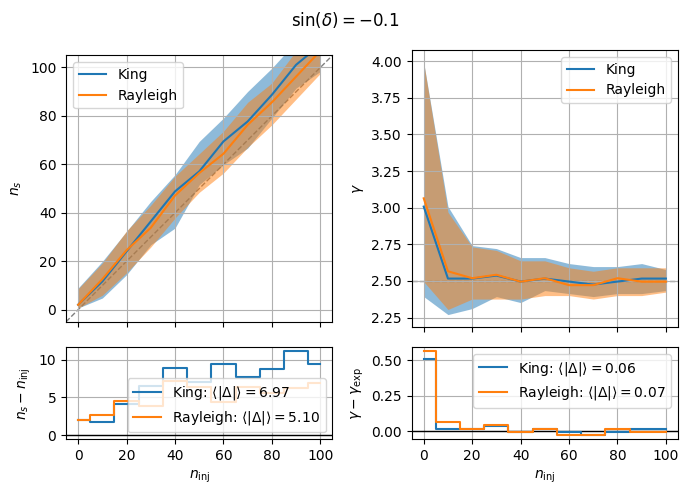

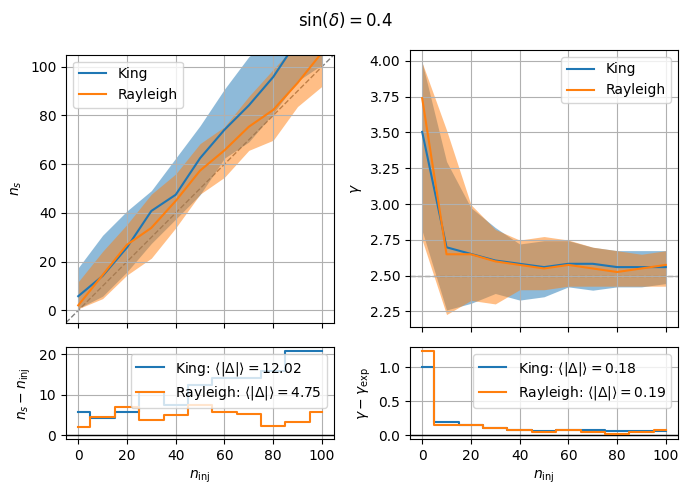

In [7]:
for s in sin_decs:
    rayleigh = rayleigh_data[s]
    king_ps = ps_energy_bin_dict[s]
    plot_bias(data_1= king_ps,
            data_2 = rayleigh,
            sindec= s,
            label_1= 'King',
            label_2= 'Rayleigh',
            ns_bins = ns_bins,
            expect_gamma= expect_gamma)